# Phân Tích Khám Phá Dữ Liệu Thị Trường Xe Ô Tô Cũ (EDA)

Notebook này thực hiện phân tích thống kê mô tả và trực quan hóa các đặc trưng trọng yếu của thị trường xe ô tô cũ tại Việt Nam từ tập dữ liệu sạch `data/processed/cars_cleaned.csv`.

Mục tiêu phân tích:
1. Thống kê mô tả tổng quan các biến số định lượng cốt lõi.
2. Khảo sát hình dạng phân phối của Giá bán, ODO và Năm sản xuất.
3. So sánh cấu trúc giá giữa các thương hiệu xe phổ biến.
4. Đánh giá quy luật khấu hao giá trị xe theo thời gian sử dụng và quãng đường lăn bánh.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Thiết lập đường dẫn động từ thư mục gốc dự án
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
DATA_PATH = ROOT / "data" / "processed" / "cars_cleaned.csv"

# Cấu hình phong cách biểu đồ chuẩn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.autolayout'] = True
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Đã nạp dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột")

Đã nạp dữ liệu: 13,520 dòng x 34 cột


## 1. Thống Kê Mô Tả (Descriptive Statistics)

Phần này cung cấp các chỉ số thống kê cơ bản (trung bình, trung vị, độ lệch chuẩn, khoảng phân vị) cho 4 biến số số học trọng tâm: Giá bán (`price_million`), Số km đã đi (`mileage_v2`), Năm sản xuất (`mfdate`), và Tuổi xe (`car_age`).

Nhận xét dữ liệu:
- Mức giá trung vị đạt 425 triệu VNĐ, thấp hơn mức giá trung bình (456,5 triệu VNĐ), thể hiện thị trường có độ lệch phải về phía phân khúc trung bình và cao cấp.
- Số ODO trung vị là khoảng 65.000 km, với 50% xe tập trung trong khoảng từ 28.000 km đến 100.000 km (khoảng liên phân vị Q1 - Q3).
- Tuổi xe trung vị là 6 năm (năm sản xuất 2020), phản ánh nguồn cung xe cũ dồi dào nhất là nhóm xe đã qua sử dụng từ 3 đến 8 năm.

In [2]:
num_cols = ['price_million', 'mileage_v2', 'mfdate', 'car_age']
stats_df = df[num_cols].describe().round(2)
stats_df.index = ['Số lượng', 'Trung bình', 'Độ lệch chuẩn', 'Nhỏ nhất', 'Phân vị 25%', 'Trung vị (50%)', 'Phân vị 75%', 'Lớn nhất']
stats_df

,price_million,mileage_v2,mfdate,car_age
Số lượng,13520.00,13520.00,13520.00,13520.00
Trung bình,456.46,68326.41,2018.26,7.74
Độ lệch chuẩn,245.75,49012.72,5.99,5.99
Nhỏ nhất,20.00,0.00,1980.00,0.00
Phân vị 25%,275.00,28000.00,2016.00,3.00
Trung vị (50%),425.00,64999.50,2020.00,6.00
Phân vị 75%,605.00,100000.00,2023.00,10.00
Lớn nhất,1180.00,204601.00,2026.00,46.00


## 2. Phân Phối Giá Xe Bán (Price Distribution)

Ý nghĩa biểu đồ:
- Biểu đồ kết hợp biểu đồ tần số (Histogram) và đường ước lượng mật độ hạt nhân (KDE) nhằm xác định hình dạng phân phối của giá xe niêm yết trên thị trường.
- Đường nét đứt màu đỏ biểu diễn giá trị trung vị (425 triệu VNĐ).

Nhận xét kinh doanh:
- Phân phối giá lệch phải rõ rệt: phần lớn xe cũ giao dịch tập trung ở tầm giá 250 - 600 triệu VNĐ (chiếm hơn 60% thị phần).
- Số lượng xe giảm dần khi tiến về các mức giá trên 800 triệu VNĐ và đạt ngưỡng trần của tập dữ liệu sau lọc ngoại lai là 1.180 triệu VNĐ.

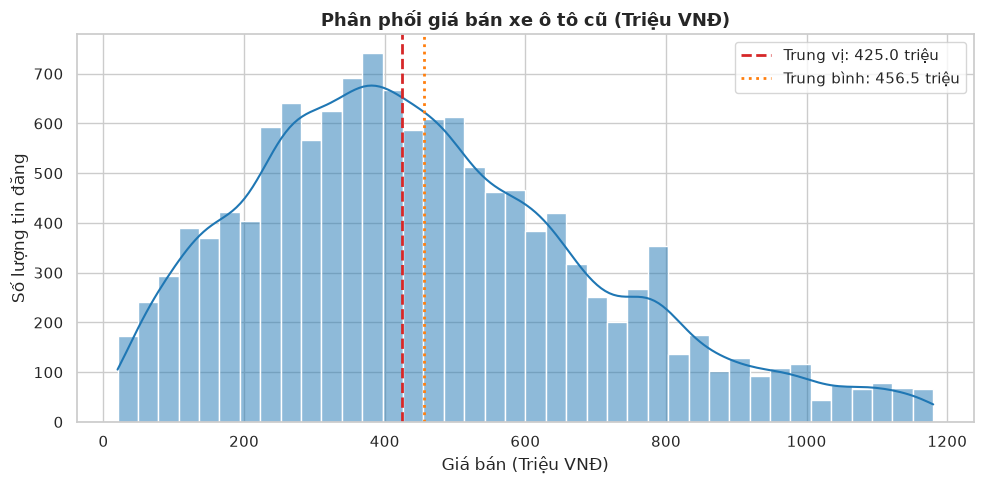

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['price_million'], bins=40, kde=True, color='#1f77b4', ax=ax)

median_price = df['price_million'].median()
mean_price = df['price_million'].mean()

ax.axvline(median_price, color='#d62728', linestyle='--', linewidth=2, label=f'Trung vị: {median_price:.1f} triệu')
ax.axvline(mean_price, color='#ff7f0e', linestyle=':', linewidth=2, label=f'Trung bình: {mean_price:.1f} triệu')

ax.set_title('Phân phối giá bán xe ô tô cũ (Triệu VNĐ)', fontsize=13, fontweight='bold')
ax.set_xlabel('Giá bán (Triệu VNĐ)')
ax.set_ylabel('Số lượng tin đăng')
ax.legend()
plt.show()

## 3. Phân Phối Số Kilomet Đã Đi (ODO Distribution)

Ý nghĩa biểu đồ:
- Khảo sát tần suất quãng đường đã vận hành của các xe rao bán, giúp định vị phân khúc xe lướt (dưới 30.000 km) và xe sử dụng nhiều (trên 100.000 km).
- Đường nét đứt thể hiện trung vị ODO (65.000 km).

Nhận xét kinh doanh:
- ODO tập trung cao nhất ở khoảng 30.000 - 80.000 km. Đây là thời điểm xe thường hết hạn bảo hành chính hãng (thường là 3 năm hoặc 100.000 km), thúc đẩy chủ xe bán lại để nâng cấp dòng xe mới.
- Sau mốc 150.000 km, số lượng tin giảm mạnh do tâm lý người mua e ngại chi phí bảo dưỡng định kỳ các bộ phận hao mòn lớn.

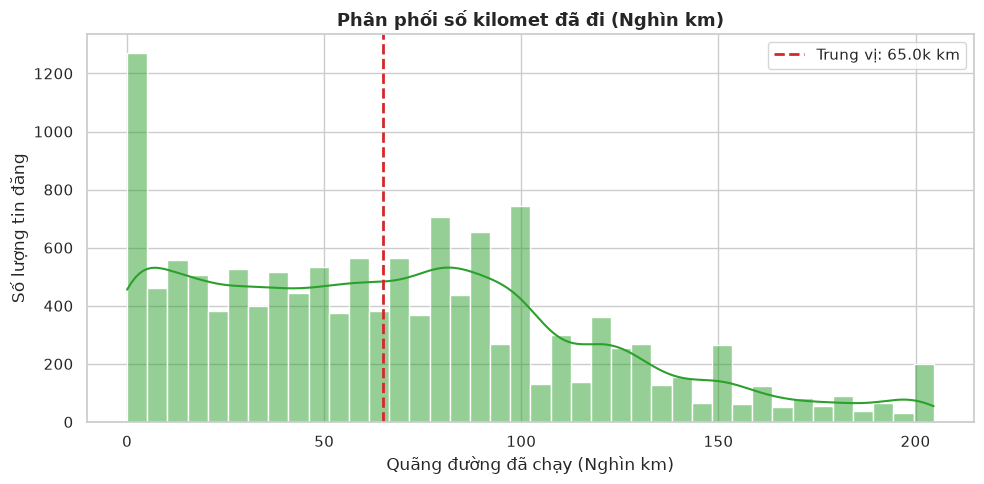

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['mileage_v2'] / 1000, bins=40, kde=True, color='#2ca02c', ax=ax)

median_odo_k = df['mileage_v2'].median() / 1000
ax.axvline(median_odo_k, color='#d62728', linestyle='--', linewidth=2, label=f'Trung vị: {median_odo_k:.1f}k km')

ax.set_title('Phân phối số kilomet đã đi (Nghìn km)', fontsize=13, fontweight='bold')
ax.set_xlabel('Quãng đường đã chạy (Nghìn km)')
ax.set_ylabel('Số lượng tin đăng')
ax.legend()
plt.show()

## 4. Phân Phối Lượng Xe Theo Năm Sản Xuất (Manufacturing Year)

Ý nghĩa biểu đồ:
- Biểu đồ cột biểu diễn số lượng xe rao bán theo từng năm sản xuất (khảo sát từ năm 2005 đến 2026).

Nhận xét kinh doanh:
- Nguồn cung xe cũ trên thị trường tăng trưởng mạnh từ đời 2016 và đạt đỉnh ở các năm 2021 - 2023.
- Các dòng xe đời sâu (trước năm 2012) chiếm tỷ trọng nhỏ (dưới 10%), chủ yếu phục vụ nhu cầu xe giá rẻ tập lái hoặc chạy dịch vụ ở các tỉnh thành xa.

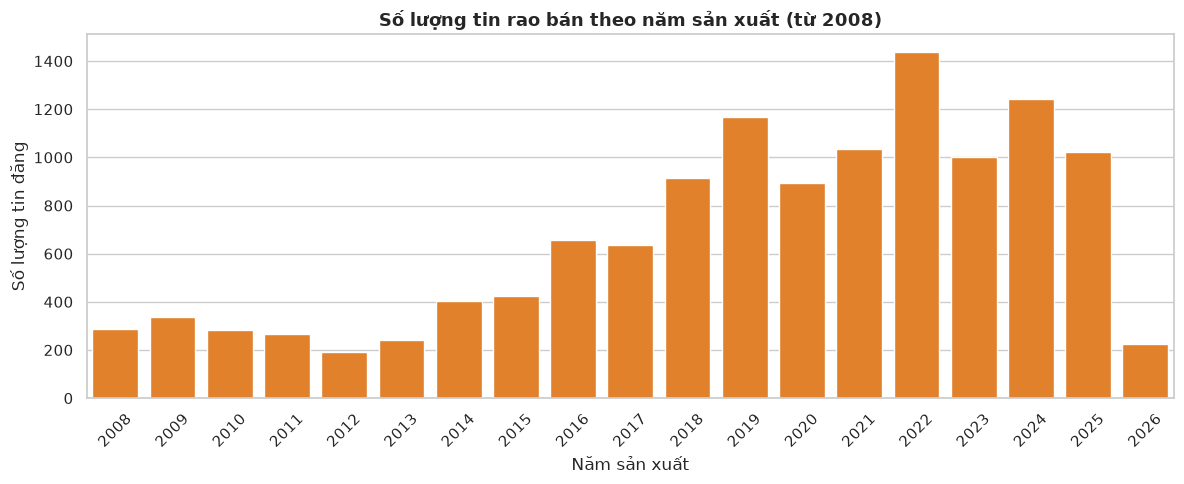

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
recent_years = df[df['mfdate'] >= 2008]['mfdate'].value_counts().sort_index()

sns.barplot(x=recent_years.index.astype(int), y=recent_years.values, color='#ff7f0e', ax=ax)
ax.set_title('Số lượng tin rao bán theo năm sản xuất (từ 2008)', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm sản xuất')
ax.set_ylabel('Số lượng tin đăng')
ax.tick_params(axis='x', rotation=45)
plt.show()

## 5. Giá Xe Theo Hãng Sản Xuất (Top 10 Thương Hiệu Phổ Biến)

Ý nghĩa biểu đồ:
- Biểu đồ hộp (Boxplot) so sánh mức giá và độ biến động giá giữa 10 hãng xe có số lượng tin đăng nhiều nhất trên thị trường.
- Các hãng được sắp xếp theo thứ tự trung vị giá giảm dần. Đường kẻ bên trong hộp thể hiện trung vị giá của từng hãng.

Nhận xét kinh doanh:
- Phân khúc hạng sang (Mercedes-Benz) có mức giá trung vị vượt trội (> 750 triệu VNĐ) và khoảng biến thiên rộng nhất.
- Nhóm xe Nhật và Mỹ phân khúc C/D/SUV (Ford, Mazda, Toyota) có mức giá trung vị ổn định trong khoảng 450 - 550 triệu VNĐ.
- Nhóm xe phổ thông Hàn Quốc (Kia, Hyundai) có mức giá trung vị thấp hơn (350 - 430 triệu VNĐ) do tỷ trọng lớn các mẫu xe đô thị cỡ nhỏ (Morning, i10, Accent).

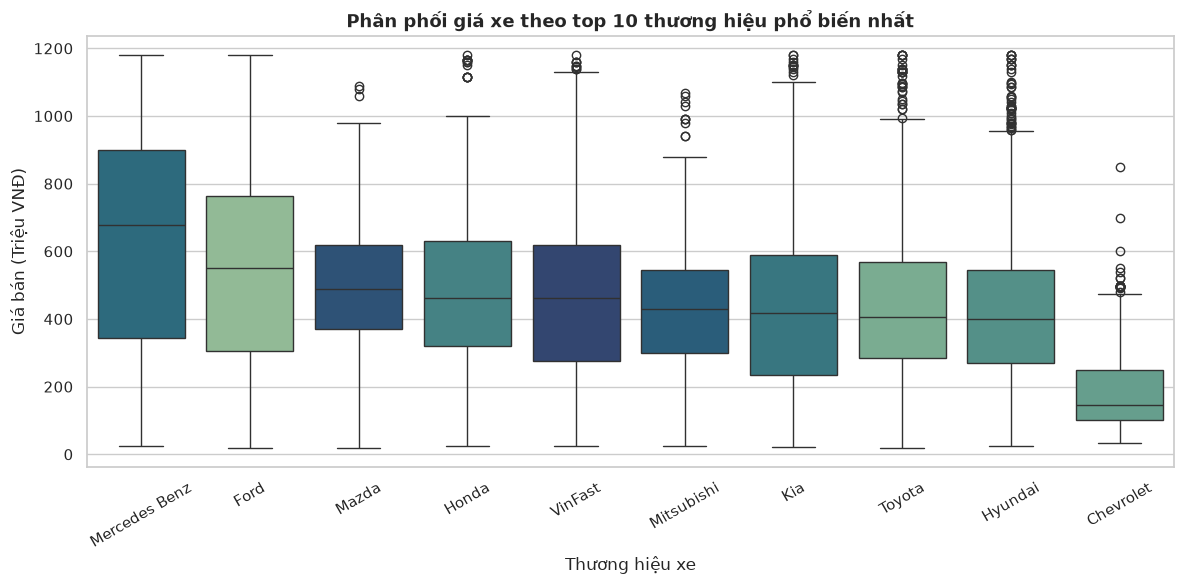

In [6]:
top_brands = df['carbrand_name'].value_counts().head(10).index
df_top = df[df['carbrand_name'].isin(top_brands)]
brand_order = df_top.groupby('carbrand_name')['price_million'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=df_top,
    x='carbrand_name',
    y='price_million',
    order=brand_order,
    hue='carbrand_name',
    palette='crest',
    legend=False,
    ax=ax
)

ax.set_title('Phân phối giá xe theo top 10 thương hiệu phổ biến nhất', fontsize=13, fontweight='bold')
ax.set_xlabel('Thương hiệu xe')
ax.set_ylabel('Giá bán (Triệu VNĐ)')
ax.tick_params(axis='x', rotation=30)
plt.show()

## 6. Khấu Hao Giá Theo Năm Sản Xuất

Ý nghĩa biểu đồ:
- Biểu đồ đường (Line plot) mô tả mức giá trung vị và giá trung bình theo từng năm sản xuất từ 2008 đến 2026.
- Cho thấy độ dốc giảm giá theo thời gian của ô tô đã qua sử dụng.

Nhận xét kinh doanh:
- Xe ô tô khấu hao nhanh nhất trong 3 năm đầu tiên sau khi xuất xưởng (mất giá trung bình 8% - 12%/năm do chi phí lăn bánh ban đầu và thuế phí).
- Từ năm thứ 4 đến năm thứ 8, tốc độ mất giá chậm lại và đi vào giai đoạn ổn định (khoảng 4% - 6%/năm).
- Các xe trên 10 năm tuổi có mức giá tiệm cận mức sàn bảo lưu giá trị (khoảng 150 - 250 triệu VNĐ) tùy thuộc vào tình trạng vận hành của khung gầm và động cơ.

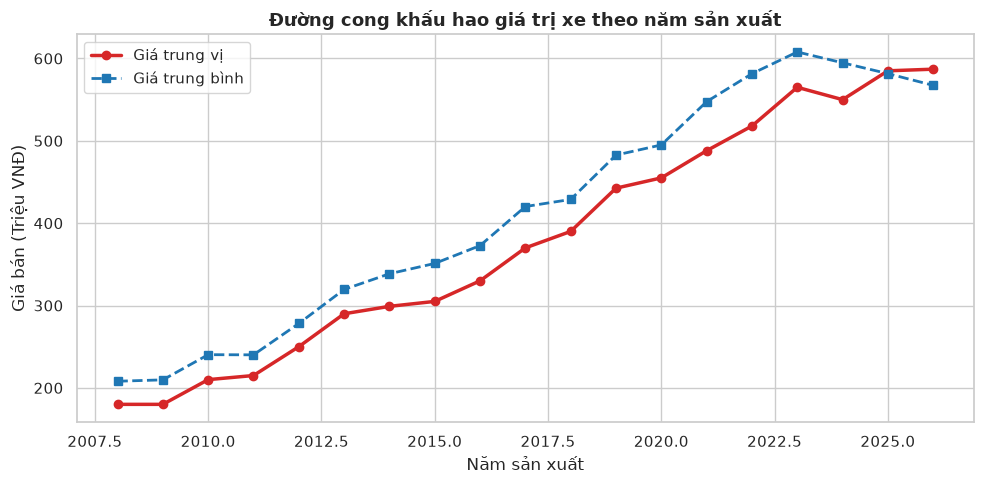

In [7]:
price_by_year = df[df['mfdate'] >= 2008].groupby('mfdate')['price_million'].agg(['median', 'mean']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(price_by_year['mfdate'], price_by_year['median'], marker='o', linewidth=2.5, color='#d62728', label='Giá trung vị')
ax.plot(price_by_year['mfdate'], price_by_year['mean'], marker='s', linewidth=2, linestyle='--', color='#1f77b4', label='Giá trung bình')

ax.set_title('Đường cong khấu hao giá trị xe theo năm sản xuất', fontsize=13, fontweight='bold')
ax.set_xlabel('Năm sản xuất')
ax.set_ylabel('Giá bán (Triệu VNĐ)')
ax.legend()
plt.show()

## 7. Khấu Hao Giá Theo Quãng Đường Lăn Bánh (ODO)

Ý nghĩa biểu đồ:
- Biểu đồ phân tán (Scatter plot) kết hợp đường hồi quy tuyến tính (Trendline) biểu thị tác động của số km đã đi (`mileage_v2`) lên giá bán (`price_million`).

Nhận xét kinh doanh:
- Hệ số tương quan nghịch: Quãng đường lăn bánh càng lớn thì giá bán bình quân càng giảm.
- Tuy nhiên, độ phân tán quanh đường hồi quy tương đối rộng: một chiếc xe sang (như Mercedes-Benz E-Class) chạy 80.000 km vẫn có giá trị cao hơn đáng kể so với một chiếc xe hạng A (như Kia Morning) chỉ mới chạy 20.000 km. Điều này chứng minh rằng mô hình định giá cần kết hợp đa biến giữa thương hiệu, dòng xe, năm sản xuất và ODO thay vì chỉ dựa vào số km.

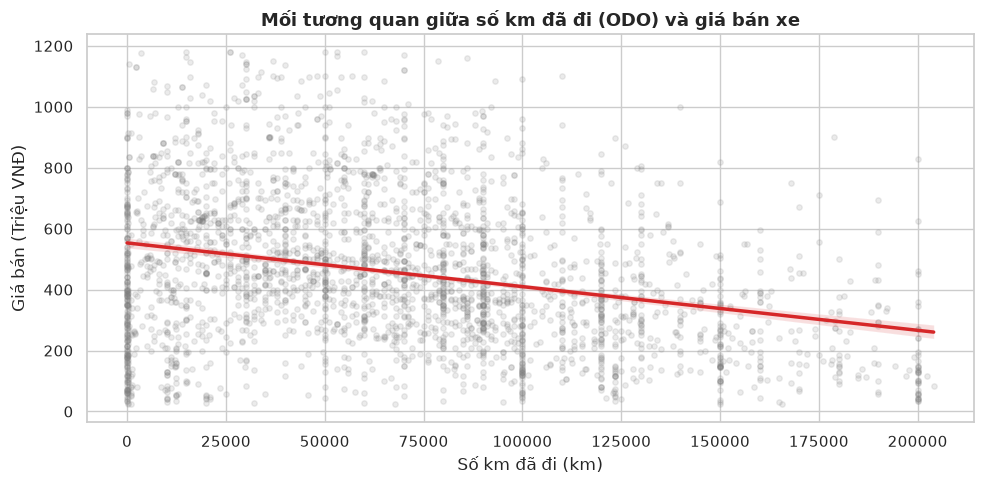

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

# Lấy mẫu ngẫu nhiên có cố định seed để biểu đồ rõ nét, tránh chồng lấp điểm quá dày
sample_df = df.sample(n=min(3000, len(df)), random_state=42)

sns.regplot(
    data=sample_df,
    x='mileage_v2',
    y='price_million',
    scatter_kws={'alpha': 0.15, 'color': '#7f7f7f', 's': 15},
    line_kws={'color': '#d62728', 'linewidth': 2.5},
    ax=ax
)

ax.set_title('Mối tương quan giữa số km đã đi (ODO) và giá bán xe', fontsize=13, fontweight='bold')
ax.set_xlabel('Số km đã đi (km)')
ax.set_ylabel('Giá bán (Triệu VNĐ)')
plt.show()